In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline

from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix)
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

import xgboost as xgb
import lightgbm as lgb
import shap

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df1 = pd.read_csv('/content/drive/MyDrive/cricket_dataset/Match Dataset.csv')
df1.head()

,Unnamed: 0,match_id,date,venue,city,team1,team2,toss_winner,toss_decision,winner,...,team1_player7,team2_player7,team1_player8,team2_player8,team1_player9,team2_player9,team1_player10,team2_player10,team1_player11,team2_player11
0,0,4143,2019-05-30,Kennington Oval,London,England,South Africa,1,field,0,...,MM Ali,D Pretorius,CR Woakes,AL Phehlukwayo,LE Plunkett,K Rabada,JC Archer,L Ngidi,AU Rashid,Imran Tahir
1,1,4144,2019-05-31,Trent Bridge,Nottingham,Pakistan,West Indies,1,field,1,...,Imad Wasim,JO Holder,Shadab Khan,CR Brathwaite,Hasan Ali,AR Nurse,Wahab Riaz,SS Cottrell,Mohammad Amir,O Thomas
2,2,4145,2019-06-01,Sophia Gardens,Cardiff,New Zealand,Sri Lanka,0,field,0,...,C de Grandhomme,BMAJ Mendis,MJ Santner,NLTC Perera,MJ Henry,I Udana,LH Ferguson,RAS Lakmal,TA Boult,SL Malinga
3,3,4147,2019-06-02,Kennington Oval,London,Bangladesh,South Africa,1,field,0,...,Mosaddek Hossain,AL Phehlukwayo,Mehedi Hasan Miraz,CH Morris,Mohammad Saifuddin,K Rabada,Mashrafe Mortaza,Imran Tahir,Mustafizur Rahman,L Ngidi
4,4,4148,2019-06-03,Trent Bridge,Nottingham,England,Pakistan,0,field,1,...,MM Ali,Shoaib Malik,CR Woakes,Wahab Riaz,JC Archer,Hasan Ali,AU Rashid,Shadab Khan,MA Wood,Mohammad Amir


In [4]:
df2 = pd.read_csv('/content/drive/MyDrive/cricket_dataset/Ball_by_Ball Dataset.csv')
df2.head()

,Unnamed: 0,match_id,inning,batting_team,bowling_team,over,ball_in_over,batter,bowler,runs_off_bat,...,balls_bowled,run_rate,target_runs,target_overs,runs_remaining,balls_remaining,required_run_rate,projected_score,pressure_index,winner
0,0,4143,1,England,South Africa,0,1,JJ Roy,Imran Tahir,1,...,1,6.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,England
1,1,4143,1,England,South Africa,0,2,JM Bairstow,Imran Tahir,0,...,2,3.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,England
2,2,4143,1,England,South Africa,0,3,JE Root,Imran Tahir,0,...,3,2.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,England
3,3,4143,1,England,South Africa,0,4,JE Root,Imran Tahir,0,...,4,1.5,NaN,NaN,NaN,NaN,NaN,0.0,NaN,England
4,4,4143,1,England,South Africa,0,5,JE Root,Imran Tahir,0,...,5,1.2,NaN,NaN,NaN,NaN,NaN,0.0,NaN,England


# **Phase 1: Exploratory Data Analysis (EDA)**

In [5]:
print("Match Dataset Shape:", df1.shape)
df1.describe()

Match Dataset Shape: (241, 32)


,Unnamed: 0,match_id,toss_winner,winner
count,241.000000,241.000000,241.000000,241.00000
mean,120.000000,3247.004149,0.510373,0.40249
std,69.714896,940.885622,0.500933,0.49142
min,0.000000,1942.000000,0.000000,0.00000
25%,60.000000,2547.000000,0.000000,0.00000
50%,120.000000,3129.000000,1.000000,0.00000
75%,180.000000,4159.000000,1.000000,1.00000
max,240.000000,4705.000000,1.000000,1.00000


In [6]:
print("Ball-by-Ball Dataset Shape:", df2.shape)
df2.describe()

Ball-by-Ball Dataset Shape: (129397, 28)


,Unnamed: 0,match_id,inning,over,ball_in_over,runs_off_bat,extras,total_runs,is_wicket,current_score,partnership_runs,wickets_lost,balls_bowled,run_rate,target_runs,target_overs,runs_remaining,balls_remaining,required_run_rate,projected_score
count,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,129397.000000,58699.000000,58699.000000,58699.000000,58699.000000,58348.000000,129397.000000
mean,64698.000000,3264.159540,1.484007,22.240647,3.600941,0.806951,0.052521,0.859471,0.027628,111.728224,27.856565,2.962457,141.229325,4.598069,268.362545,49.272792,165.586552,164.461023,7.932353,103.530337
std,37353.840728,940.437417,0.499746,13.857640,1.796863,1.294461,0.308777,1.301917,0.163906,77.954069,32.925981,2.359426,85.295228,1.554857,69.169025,3.396990,88.894044,81.906507,16.732216,126.133616
min,0.000000,1942.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,37.000000,20.000000,-20.000000,-17.000000,-135.000000,0.000000
25%,32349.000000,2547.000000,1.000000,10.000000,2.000000,0.000000,0.000000,0.000000,0.000000,48.000000,5.000000,1.000000,68.000000,3.677419,220.000000,50.000000,96.000000,98.000000,4.352841,0.000000
50%,64698.000000,3131.000000,1.000000,21.000000,4.000000,0.000000,0.000000,0.000000,0.000000,101.000000,16.000000,3.000000,137.000000,4.513761,271.000000,50.000000,162.000000,170.000000,6.277117,0.000000
75%,97047.000000,4162.000000,2.000000,34.000000,5.000000,1.000000,0.000000,1.000000,0.000000,163.000000,39.000000,4.000000,212.000000,5.508621,319.000000,50.000000,232.000000,235.000000,8.335015,214.285714
max,129396.000000,4705.000000,2.000000,49.000000,14.000000,6.000000,5.000000,7.000000,1.000000,428.000000,348.000000,10.000000,323.000000,33.000000,429.000000,50.000000,429.000000,299.000000,1338.000000,1650.000000


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      241 non-null    int64 
 1   match_id        241 non-null    int64 
 2   date            241 non-null    object
 3   venue           241 non-null    object
 4   city            241 non-null    object
 5   team1           241 non-null    object
 6   team2           241 non-null    object
 7   toss_winner     241 non-null    int64 
 8   toss_decision   241 non-null    object
 9   winner          241 non-null    int64 
 10  team1_player1   241 non-null    object
 11  team2_player1   241 non-null    object
 12  team1_player2   241 non-null    object
 13  team2_player2   241 non-null    object
 14  team1_player3   241 non-null    object
 15  team2_player3   241 non-null    object
 16  team1_player4   241 non-null    object
 17  team2_player4   241 non-null    object
 18  team1_play

In [8]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129397 entries, 0 to 129396
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         129397 non-null  int64  
 1   match_id           129397 non-null  int64  
 2   inning             129397 non-null  int64  
 3   batting_team       129397 non-null  object 
 4   bowling_team       129397 non-null  object 
 5   over               129397 non-null  int64  
 6   ball_in_over       129397 non-null  int64  
 7   batter             129397 non-null  object 
 8   bowler             129397 non-null  object 
 9   runs_off_bat       129397 non-null  int64  
 10  extras             129397 non-null  int64  
 11  total_runs         129397 non-null  int64  
 12  is_wicket          129397 non-null  int64  
 13  wicket_type        3575 non-null    object 
 14  player_out         3575 non-null    object 
 15  current_score      129397 non-null  int64  
 16  pa

#**Identify columns with missing values**

In [9]:
# Identify columns with missing data
missing_columns1 = df1.columns[df1.isnull().any()]

print("Columns with missing data:", missing_columns1.tolist())

# To check the count of missing values in each column
print(df1.isnull().sum())

Columns with missing data: []
Unnamed: 0        0
match_id          0
date              0
venue             0
city              0
team1             0
team2             0
toss_winner       0
toss_decision     0
winner            0
team1_player1     0
team2_player1     0
team1_player2     0
team2_player2     0
team1_player3     0
team2_player3     0
team1_player4     0
team2_player4     0
team1_player5     0
team2_player5     0
team1_player6     0
team2_player6     0
team1_player7     0
team2_player7     0
team1_player8     0
team2_player8     0
team1_player9     0
team2_player9     0
team1_player10    0
team2_player10    0
team1_player11    0
team2_player11    0
dtype: int64


In [10]:
# Identify columns with missing data
missing_columns2 = df2.columns[df2.isnull().any()]

print("Columns with missing data:", missing_columns2.tolist())

# To check the count of missing values in each column
print(df2.isnull().sum())

Columns with missing data: ['wicket_type', 'player_out', 'target_runs', 'target_overs', 'runs_remaining', 'balls_remaining', 'required_run_rate', 'pressure_index']
Unnamed: 0                0
match_id                  0
inning                    0
batting_team              0
bowling_team              0
over                      0
ball_in_over              0
batter                    0
bowler                    0
runs_off_bat              0
extras                    0
total_runs                0
is_wicket                 0
wicket_type          125822
player_out           125822
current_score             0
partnership_runs          0
wickets_lost              0
balls_bowled              0
run_rate                  0
target_runs           70698
target_overs          70698
runs_remaining        70698
balls_remaining       70698
required_run_rate     71049
projected_score           0
pressure_index        71049
winner                    0
dtype: int64


In [11]:
cols_2nd_innings = [
    'target_runs', 'target_overs', 'runs_remaining',
    'balls_remaining', 'required_run_rate'
]

for col in cols_2nd_innings:
    # Conditional imputation
    df2.loc[df2['inning'] == 1, col] = df2.loc[df2['inning'] == 1, col].fillna(0)

    # Mean imputation for 2nd innings
    mean_value = df2.loc[df2['inning'] == 2, col].mean()
    df2.loc[df2['inning'] == 2, col] = df2.loc[df2['inning'] == 2, col].fillna(mean_value)

#For wicket-related columns, fill missing values with 'Not out'
df2['wicket_type'] = df2['wicket_type'].fillna('Not out')
df2['player_out'] = df2['player_out'].fillna('Not out')

In [12]:
df2.loc[df2['inning'] == 1, 'pressure_index'] = df2.loc[df2['inning'] == 1, 'pressure_index'].fillna('NA')

second_innings_mode = df2.loc[df2['inning'] == 2, 'pressure_index'].mode()
if not second_innings_mode.empty:
    mode_value = second_innings_mode[0]
else:
    mode_value = 'medium'  # fallback value
df2.loc[df2['inning'] == 2, 'pressure_index'] = df2.loc[df2['inning'] == 2, 'pressure_index'].fillna(mode_value)

In [13]:
print("\nDataFrame after handling columns with missing values:\n", df2.isnull().sum())


DataFrame after handling columns with missing values:
 Unnamed: 0           0
match_id             0
inning               0
batting_team         0
bowling_team         0
over                 0
ball_in_over         0
batter               0
bowler               0
runs_off_bat         0
extras               0
total_runs           0
is_wicket            0
wicket_type          0
player_out           0
current_score        0
partnership_runs     0
wickets_lost         0
balls_bowled         0
run_rate             0
target_runs          0
target_overs         0
runs_remaining       0
balls_remaining      0
required_run_rate    0
projected_score      0
pressure_index       0
winner               0
dtype: int64


In [14]:
# Count duplicate rows
print("Duplicate Rows:", df1.duplicated().sum())

# Display duplicate rows
df1[df1.duplicated()]

Duplicate Rows: 0


,Unnamed: 0,match_id,date,venue,city,team1,team2,toss_winner,toss_decision,winner,...,team1_player7,team2_player7,team1_player8,team2_player8,team1_player9,team2_player9,team1_player10,team2_player10,team1_player11,team2_player11


In [15]:
# Count duplicate rows
print("Duplicate Rows:", df2.duplicated().sum())

# Display duplicate rows
df2[df2.duplicated()]

Duplicate Rows: 0


,Unnamed: 0,match_id,inning,batting_team,bowling_team,over,ball_in_over,batter,bowler,runs_off_bat,...,balls_bowled,run_rate,target_runs,target_overs,runs_remaining,balls_remaining,required_run_rate,projected_score,pressure_index,winner


In [16]:
df2.head()

,Unnamed: 0,match_id,inning,batting_team,bowling_team,over,ball_in_over,batter,bowler,runs_off_bat,...,balls_bowled,run_rate,target_runs,target_overs,runs_remaining,balls_remaining,required_run_rate,projected_score,pressure_index,winner
0,0,4143,1,England,South Africa,0,1,JJ Roy,Imran Tahir,1,...,1,6.0,0.0,0.0,0.0,0.0,0.0,0.0,NA,England
1,1,4143,1,England,South Africa,0,2,JM Bairstow,Imran Tahir,0,...,2,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NA,England
2,2,4143,1,England,South Africa,0,3,JE Root,Imran Tahir,0,...,3,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NA,England
3,3,4143,1,England,South Africa,0,4,JE Root,Imran Tahir,0,...,4,1.5,0.0,0.0,0.0,0.0,0.0,0.0,NA,England
4,4,4143,1,England,South Africa,0,5,JE Root,Imran Tahir,0,...,5,1.2,0.0,0.0,0.0,0.0,0.0,0.0,NA,England


# **Merging Datasets**

In [17]:
df = pd.merge(df1, df2, on='match_id', how='inner')
df.head()

,Unnamed: 0_x,match_id,date,venue,city,team1,team2,toss_winner,toss_decision,winner_x,...,balls_bowled,run_rate,target_runs,target_overs,runs_remaining,balls_remaining,required_run_rate,projected_score,pressure_index,winner_y
0,0,4143,2019-05-30,Kennington Oval,London,England,South Africa,1,field,0,...,1,6.0,0.0,0.0,0.0,0.0,0.0,0.0,NA,England
1,0,4143,2019-05-30,Kennington Oval,London,England,South Africa,1,field,0,...,2,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NA,England
2,0,4143,2019-05-30,Kennington Oval,London,England,South Africa,1,field,0,...,3,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NA,England
3,0,4143,2019-05-30,Kennington Oval,London,England,South Africa,1,field,0,...,4,1.5,0.0,0.0,0.0,0.0,0.0,0.0,NA,England
4,0,4143,2019-05-30,Kennington Oval,London,England,South Africa,1,field,0,...,5,1.2,0.0,0.0,0.0,0.0,0.0,0.0,NA,England


# **Outlier Detection**

In [18]:
# Define numeric columns
numeric_cols = ['runs_off_bat', 'total_runs', 'target_runs', 'target_overs',
                'runs_remaining', 'balls_remaining', 'required_run_rate']

# Outlier treatment: IQR capping
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

# **Normalizing Numerical Features**

In [19]:
#scaler = StandardScaler()
#df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


**Unique Classes**

In [20]:
print("Number of unique classes:", df['winner_y'].nunique())
print(df['winner_y'].value_counts())

Number of unique classes: 14
winner_y
Australia       21121
India           20074
New Zealand     16562
South Africa    13179
Sri Lanka       12067
England         11789
Pakistan        10285
West Indies      6465
Bangladesh       5542
Ireland          4155
Zimbabwe         2772
Kenya            2235
Netherlands      2071
Canada           1080
Name: count, dtype: int64


In [21]:
df['date'] = pd.to_datetime(df['date'])

#**Feature Engineering**

In [22]:
print(df.columns)

Index(['Unnamed: 0_x', 'match_id', 'date', 'venue', 'city', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'winner_x', 'team1_player1',
       'team2_player1', 'team1_player2', 'team2_player2', 'team1_player3',
       'team2_player3', 'team1_player4', 'team2_player4', 'team1_player5',
       'team2_player5', 'team1_player6', 'team2_player6', 'team1_player7',
       'team2_player7', 'team1_player8', 'team2_player8', 'team1_player9',
       'team2_player9', 'team1_player10', 'team2_player10', 'team1_player11',
       'team2_player11', 'Unnamed: 0_y', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball_in_over', 'batter', 'bowler',
       'runs_off_bat', 'extras', 'total_runs', 'is_wicket', 'wicket_type',
       'player_out', 'current_score', 'partnership_runs', 'wickets_lost',
       'balls_bowled', 'run_rate', 'target_runs', 'target_overs',
       'runs_remaining', 'balls_remaining', 'required_run_rate',
       'projected_score', 'pressure_index', 'winner_y'],
     

**Player Form (Rolling Average)**

In [23]:
# Player's average runs in the last 5 innings
df = df.sort_values(['batter', 'date'])
df['player_form'] = df.groupby('batter')['runs_off_bat'].rolling(window=5, min_periods=1).mean().reset_index(level=0, drop=True)

**Opposition Strength (Mean runs conceded)**

In [24]:
opp_strength = df.groupby('bowling_team')['total_runs'].mean()
df['opposition_strength'] = df['bowling_team'].map(opp_strength)


**Team Level Aggregates**

In [25]:
team_avg_form = df.groupby('batting_team')['player_form'].mean()
df['team_avg_form'] = df['batting_team'].map(team_avg_form)

In [26]:
# Aggregate total runs scored by each team per match
team_totals = df.groupby(['match_id', 'batting_team'])['runs_off_bat'].sum().reset_index().rename(columns={'runs_off_bat': 'total_runs'})

if 'total_runs' in df.columns:
    df.drop(columns=['total_runs'], inplace=True, errors='ignore')

# Merge aggregated totals back into df
df = pd.merge(
    df,
    team_totals,
    on=['match_id', 'batting_team'],
    how='left'
)

In [27]:
df.head()

,Unnamed: 0_x,match_id,date,venue,city,team1,team2,toss_winner,toss_decision,winner_x,...,runs_remaining,balls_remaining,required_run_rate,projected_score,pressure_index,winner_y,player_form,opposition_strength,team_avg_form,total_runs
0,170,1946,2003-02-11,"Kingsmead, Durban",Durban,Canada,Bangladesh,0,bat,0,...,0.0,0.0,0.0,0.0,NA,Canada,1.000000,0.727277,0.462965,124.5
1,170,1946,2003-02-11,"Kingsmead, Durban",Durban,Canada,Bangladesh,0,bat,0,...,0.0,0.0,0.0,0.0,NA,Canada,0.500000,0.727277,0.462965,124.5
2,170,1946,2003-02-11,"Kingsmead, Durban",Durban,Canada,Bangladesh,0,bat,0,...,0.0,0.0,0.0,0.0,NA,Canada,0.666667,0.727277,0.462965,124.5
3,170,1946,2003-02-11,"Kingsmead, Durban",Durban,Canada,Bangladesh,0,bat,0,...,0.0,0.0,0.0,0.0,NA,Canada,0.500000,0.727277,0.462965,124.5
4,170,1946,2003-02-11,"Kingsmead, Durban",Durban,Canada,Bangladesh,0,bat,0,...,0.0,0.0,0.0,0.0,NA,Canada,0.600000,0.727277,0.462965,124.5


In [28]:
# Start with the existing DataFrame `df`
df['venue_home_advantage'] = (df['venue'] == df['team1']).astype(int)

df['toss_win_and_decision'] = ((df['toss_winner'] == df['team1']) & (df['toss_decision'] == 'bat')).astype(int)

# Wickets in hand (using ball data)
df['wickets_in_hand'] = 10 - df['wickets_lost']

# Recent form variance
player_variance = df.groupby('batter')['runs_off_bat'].rolling(window=5, min_periods=1).var().reset_index(level=0, drop=True)
df['recent_form_variance'] = player_variance.fillna(0)

# Opponent bowler strength (mean economy rate of opposing team bowlers)
bowler_economy = df.groupby('bowling_team')['runs_off_bat'].mean()
df['opponent_bowler_strength'] = df['bowling_team'].map(bowler_economy)

### **Encoding Categorical Variables**

In [29]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns:", categorical_cols)

Categorical columns: ['venue', 'city', 'team1', 'team2', 'toss_decision', 'team1_player1', 'team2_player1', 'team1_player2', 'team2_player2', 'team1_player3', 'team2_player3', 'team1_player4', 'team2_player4', 'team1_player5', 'team2_player5', 'team1_player6', 'team2_player6', 'team1_player7', 'team2_player7', 'team1_player8', 'team2_player8', 'team1_player9', 'team2_player9', 'team1_player10', 'team2_player10', 'team1_player11', 'team2_player11', 'batting_team', 'bowling_team', 'batter', 'bowler', 'wicket_type', 'player_out', 'pressure_index', 'winner_y']


In [30]:
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'unique_classes': df.nunique()
})

print(summary)

                                   dtype  unique_classes
Unnamed: 0_x                       int64             241
match_id                           int64             241
date                      datetime64[ns]             192
venue                             object              66
city                              object              60
...                                  ...             ...
venue_home_advantage               int64               1
toss_win_and_decision              int64               1
wickets_in_hand                    int64              11
recent_form_variance             float64            1436
opponent_bowler_strength         float64              18

[67 rows x 2 columns]


In [31]:
# Columns to encode
df_encoded = pd.get_dummies(df,
                            columns=['venue', 'city', 'team1', 'team2',
                                     'toss_decision', 'bowling_team',
                                     'pressure_index', 'batting_team'],
                            drop_first=False)

# Preview the encoded DataFrame
df_encoded.head()


,Unnamed: 0_x,match_id,date,toss_winner,winner_x,team1_player1,team2_player1,team1_player2,team2_player2,team1_player3,...,batting_team_Namibia,batting_team_Netherlands,batting_team_New Zealand,batting_team_Pakistan,batting_team_Scotland,batting_team_South Africa,batting_team_Sri Lanka,batting_team_United Arab Emirates,batting_team_West Indies,batting_team_Zimbabwe
0,170,1946,2003-02-11,0,0,I Maraj,Hannan Sarkar,JM Davison,Al Sahariar,DR Chumney,...,False,False,False,False,False,False,False,False,False,False
1,170,1946,2003-02-11,0,0,I Maraj,Hannan Sarkar,JM Davison,Al Sahariar,DR Chumney,...,False,False,False,False,False,False,False,False,False,False
2,170,1946,2003-02-11,0,0,I Maraj,Hannan Sarkar,JM Davison,Al Sahariar,DR Chumney,...,False,False,False,False,False,False,False,False,False,False
3,170,1946,2003-02-11,0,0,I Maraj,Hannan Sarkar,JM Davison,Al Sahariar,DR Chumney,...,False,False,False,False,False,False,False,False,False,False
4,170,1946,2003-02-11,0,0,I Maraj,Hannan Sarkar,JM Davison,Al Sahariar,DR Chumney,...,False,False,False,False,False,False,False,False,False,False


# **Clustering by Player Performance**

In [32]:
# Use player_form and total_runs for clustering
cluster_data = df[['player_form', 'total_runs']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(cluster_data)

print("\n Cluster assignment:")
print(df[['batter', 'player_form', 'total_runs', 'cluster']])


 Cluster assignment:
            batter  player_form  total_runs  cluster
0          A Bagai     1.000000       124.5        2
1          A Bagai     0.500000       124.5        2
2          A Bagai     0.666667       124.5        2
3          A Bagai     0.500000       124.5        2
4          A Bagai     0.600000       124.5        2
...            ...          ...         ...      ...
129392  ZE Surkari     0.800000       153.0        0
129393  ZE Surkari     0.800000       153.0        0
129394  ZE Surkari     0.800000       153.0        0
129395  ZE Surkari     0.600000       153.0        0
129396  ZE Surkari     0.200000       153.0        0

[129397 rows x 4 columns]


In [33]:
# Cluster summary
cluster_summary = df.groupby('cluster').agg({
    'batter': 'nunique',
    'total_runs': 'mean',
    'player_form': 'mean'
}).rename(columns={'batter': 'unique_players'})

print("\nCluster Summary:")
print(cluster_summary)



Cluster Summary:
         unique_players  total_runs  player_form
cluster                                         
0                   555  172.506516     0.601876
1                   428  235.626823     0.763000
2                   518  105.917285     0.488445


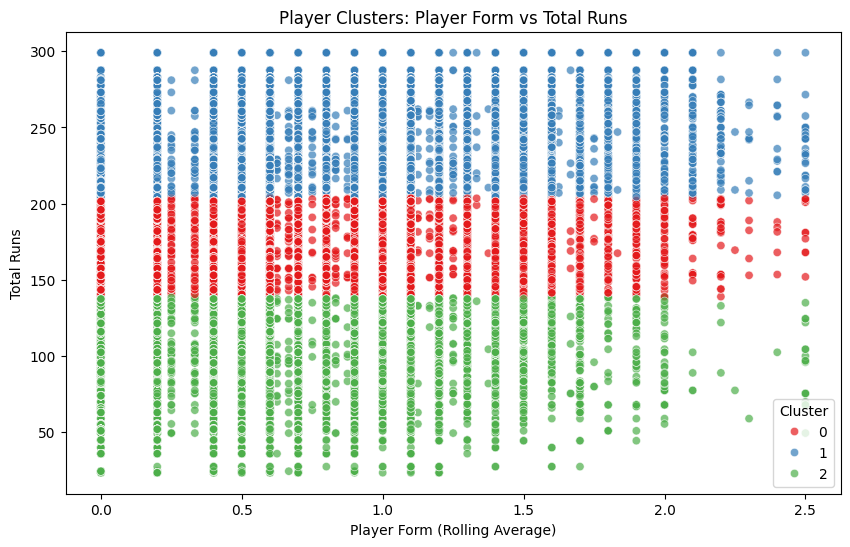

In [34]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='player_form', y='total_runs', hue='cluster', palette='Set1', alpha=0.7)
plt.title('Player Clusters: Player Form vs Total Runs')
plt.xlabel('Player Form (Rolling Average)')
plt.ylabel('Total Runs')
plt.legend(title='Cluster')
plt.show()

# **Ranking Players**

In [35]:
df['player_rank'] = df.groupby('match_id')['total_runs'].rank(ascending=False, method='dense')
print("Player ranking:")
print(df[['match_id', 'batter', 'total_runs', 'player_rank']])

Player ranking:
        match_id      batter  total_runs  player_rank
0           1946     A Bagai       124.5          1.0
1           1946     A Bagai       124.5          1.0
2           1946     A Bagai       124.5          1.0
3           1946     A Bagai       124.5          1.0
4           1946     A Bagai       124.5          1.0
...          ...         ...         ...          ...
129392      3134  ZE Surkari       153.0          1.0
129393      3134  ZE Surkari       153.0          1.0
129394      3134  ZE Surkari       153.0          1.0
129395      3134  ZE Surkari       153.0          1.0
129396      3134  ZE Surkari       153.0          1.0

[129397 rows x 4 columns]


<ipython-input-36-1558738601>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_players.values, y=top_players.index, palette='viridis')


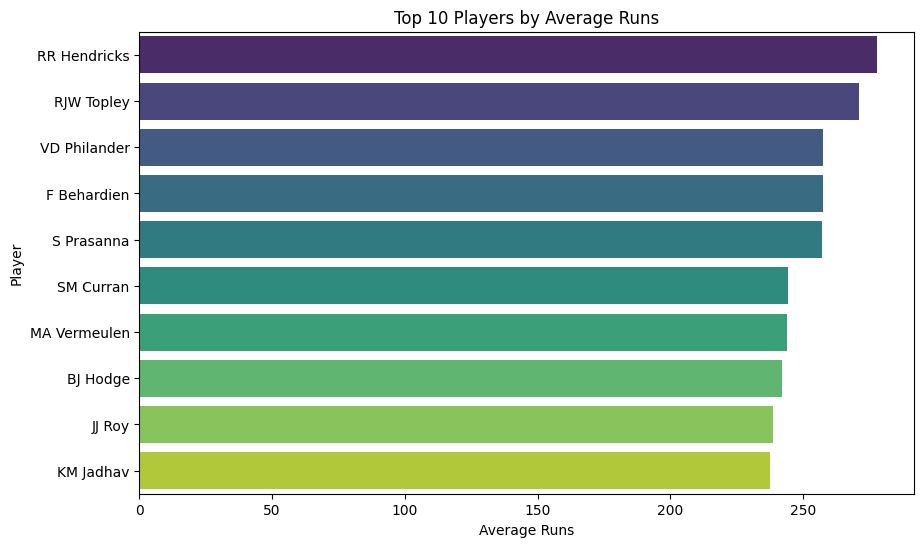

In [36]:
# Plot top 10 players by average runs
top_players = df.groupby('batter')['total_runs'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_players.values, y=top_players.index, palette='viridis')
plt.xlabel('Average Runs')
plt.ylabel('Player')
plt.title('Top 10 Players by Average Runs')
plt.show()


# **Predicting Player Performance (Regression)**

In [37]:
df.columns

Index(['Unnamed: 0_x', 'match_id', 'date', 'venue', 'city', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'winner_x', 'team1_player1',
       'team2_player1', 'team1_player2', 'team2_player2', 'team1_player3',
       'team2_player3', 'team1_player4', 'team2_player4', 'team1_player5',
       'team2_player5', 'team1_player6', 'team2_player6', 'team1_player7',
       'team2_player7', 'team1_player8', 'team2_player8', 'team1_player9',
       'team2_player9', 'team1_player10', 'team2_player10', 'team1_player11',
       'team2_player11', 'Unnamed: 0_y', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball_in_over', 'batter', 'bowler',
       'runs_off_bat', 'extras', 'is_wicket', 'wicket_type', 'player_out',
       'current_score', 'partnership_runs', 'wickets_lost', 'balls_bowled',
       'run_rate', 'target_runs', 'target_overs', 'runs_remaining',
       'balls_remaining', 'required_run_rate', 'projected_score',
       'pressure_index', 'winner_y', 'player_form', 'oppo

In [38]:
features_reg = [
    'venue_home_advantage',
    'toss_win_and_decision',
    'wickets_in_hand',
    'recent_form_variance',
    'opponent_bowler_strength',
    'player_form',
    'opposition_strength',
    'team_avg_form'
]

X_reg = df[features_reg]
y_reg = df['total_runs']

# Train-test split
from sklearn.model_selection import train_test_split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

**Random Forest Regressor**

In [39]:
rf_reg = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}
gs_rf = GridSearchCV(
    rf_reg, param_grid_rf,
    scoring='neg_mean_absolute_error',
    cv=5, n_jobs=-1, verbose=2
)
gs_rf.fit(X_train_reg, y_train_reg)

y_pred_rf = gs_rf.predict(X_test_reg)
print("===== Random Forest Regressor =====")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)))
print("R2:", r2_score(y_test_reg, y_pred_rf))
print("Best RF Params:", gs_rf.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
===== Random Forest Regressor =====
MAE: 30.886233501568192
RMSE: 39.26230394698599
R2: 0.45367693293660316
Best RF Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


**XGBoost Regressor**

In [40]:
xgb_reg = xgb.XGBRegressor(random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
gs_xgb = GridSearchCV(xgb_reg, param_grid_xgb, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1, verbose=2)
gs_xgb.fit(X_train_reg, y_train_reg)

y_pred_xgb = gs_xgb.predict(X_test_reg)
print("===== XGBoost Regressor =====")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb)))
print("R2:", r2_score(y_test_reg, y_pred_xgb))
print("Best XGB Params:", gs_xgb.best_params_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
===== XGBoost Regressor =====
MAE: 23.439741091602922
RMSE: 32.5564857199748
R2: 0.6243589769160109
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


**LightGBM Regressor**

In [41]:
import lightgbm as lgb

lgb_reg = lgb.LGBMRegressor(random_state=42)
param_grid_lgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

gs_lgb = GridSearchCV(
    lgb_reg, param_grid_lgb,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)
gs_lgb.fit(X_train_reg, y_train_reg)

y_pred_lgb = gs_lgb.predict(X_test_reg)
print("===== LightGBM Regressor =====")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_lgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_lgb)))
print("R2:", r2_score(y_test_reg, y_pred_lgb))
print("Best LGBM Params:", gs_lgb.best_params_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004372 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 272
[LightGBM] [Info] Number of data points in the train set: 103517, number of used features: 6
[LightGBM] [Info] Start training from score 179.889105
===== LightGBM Regressor =====
MAE: 26.759158007009162
RMSE: 35.300022865747856
R2: 0.5583807969679779
Best LGBM Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


**Ensemble Averaging**

In [42]:
y_pred_combined = (y_pred_rf + y_pred_xgb + y_pred_lgb) / 3

print("Combined Model MAE:", mean_absolute_error(y_test_reg, y_pred_combined))
print("Combined Model R2:", r2_score(y_test_reg, y_pred_combined))

Combined Model MAE: 26.548674631073904
Combined Model R2: 0.5680584317809378


# **Predicting Match Outcome (Classification)**

In [43]:
# Ensure 'team1_win' is created
df_encoded['team1_win'] = (df['winner_y'] == df['team1']).astype(int)

# Define all known-leaky or irrelevant columns
leak_cols = [
    'winner_y', 'winner_x', 'team1_win', 'toss_winner',
    'toss_win_and_decision', 'total_runs', 'runs_remaining',
    'projected_score', 'pressure_index' , 'batter', 'bowler', 'player_out', 'wicket_type',
    'date'
]

# Also drop all 'player' columns
leak_cols += [col for col in df_encoded.columns if 'player' in col]

# Final features and target
X_clf = df_encoded.drop(columns=leak_cols + ['team1_win'], errors='ignore')
y_clf = df_encoded['team1_win']

# Sanitize column names for models like LightGBM
X_clf.columns = X_clf.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# Train/test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


In [44]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_pred))


**Decision Tree**

In [45]:
for col in X_clf.columns:
    if 'win' in col.lower() or 'winner' in col.lower() or 'result' in col.lower():
        print(col)


In [46]:
print("Train size:", X_train_clf.shape[0])
print("Test size:", X_test_clf.shape[0])
print("Train-Test Overlap:", X_train_clf.index.intersection(X_test_clf.index).shape[0])


Train size: 103517
Test size: 25880
Train-Test Overlap: 0


In [47]:
dt_clf = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 'log2']
}
gs_dt = GridSearchCV(dt_clf, param_grid_dt, scoring='f1', cv=5, n_jobs=-1, verbose=2)
gs_dt.fit(X_train_clf, y_train_clf)

y_pred_dt = gs_dt.predict(X_test_clf)
print("Decision Tree Accuracy:", accuracy_score(y_test_clf, y_pred_dt))
print("Decision Tree F1:", f1_score(y_test_clf, y_pred_dt))
print("Best Decision Tree Params:", gs_dt.best_params_)

evaluate_model(y_test_clf, y_pred_dt, "Decision Tree")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Decision Tree Accuracy: 0.9143353941267388
Decision Tree F1: 0.9295720956828362
Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2}
===== Decision Tree =====
Accuracy: 0.9143353941267388
F1 Score: 0.9295720956828362
ROC AUC: 0.910237234004731


**Neural Network**

In [48]:
mlp = MLPClassifier(max_iter=100, early_stopping=True, n_iter_no_change=10, random_state=42)
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001]
}
gs_mlp = GridSearchCV(mlp, param_grid_mlp, scoring='f1', cv=5, n_jobs=-1, verbose=2)
gs_mlp.fit(X_train_clf, y_train_clf)

y_pred_mlp = gs_mlp.predict(X_test_clf)
print("Neural Network Accuracy:", accuracy_score(y_test_clf, y_pred_mlp))
print("Neural Network F1:", f1_score(y_test_clf, y_pred_mlp))
print("Best MLP Params:", gs_mlp.best_params_)

evaluate_model(y_test_clf, y_pred_mlp, "Neural Network")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Neural Network Accuracy: 0.8352782071097372
Neural Network F1: 0.8711967852071185
Best MLP Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50)}
===== Neural Network =====
Accuracy: 0.8352782071097372
F1 Score: 0.8711967852071185
ROC AUC: 0.8130445784848271


In [49]:
!pip install scikeras

In [50]:
!pip install --upgrade scikeras scikit-learn tensorflow

In [51]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(hidden_layer_sizes=(64,), activation="relu", dropout_rate=0.2):
    model = Sequential()
    model.add(Dense(hidden_layer_sizes[0], activation=activation, input_shape=(X_train_clf.shape[1],)))
    for units in hidden_layer_sizes[1:]:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])
    return model

clf = KerasClassifier(
    model=build_model,
    hidden_layer_sizes=(64,),
    activation="relu",
    dropout_rate=0.2,
    optimizer="adam",
    epochs=30,
    batch_size=32,
    verbose=0
)

param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (64, 64)],
    "activation": ["relu", "tanh"],
    "dropout_rate": [0.2, 0.5],
    "batch_size": [32],
    "epochs": [30]
}

grid_search = GridSearchCV(clf, param_grid=param_grid, scoring="f1", cv=3, verbose=2)
grid_search.fit(X_train_clf, y_train_clf)

y_pred = grid_search.predict(X_test_clf)

print("Best Parameters:", grid_search.best_params_)
print("Neural Network Accuracy:", accuracy_score(y_test_clf, y_pred))
print("F1 Score:", f1_score(y_test_clf, y_pred))


Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END activation=relu, batch_size=32, dropout_rate=0.2, epochs=30, hidden_layer_sizes=(64,); total time= 2.3min


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END activation=relu, batch_size=32, dropout_rate=0.2, epochs=30, hidden_layer_sizes=(64,); total time= 2.0min


...

[CV] END activation=tanh, batch_size=32, dropout_rate=0.5, epochs=30, hidden_layer_sizes=(64, 64); total time= 2.2min


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END activation=tanh, batch_size=32, dropout_rate=0.5, epochs=30, hidden_layer_sizes=(64, 64); total time= 2.1min


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Parameters: {'activation': 'relu', 'batch_size': 32, 'dropout_rate': 0.5, 'epochs': 30, 'hidden_layer_sizes': (64,)}
Neural Network Accuracy: 0.7445517774343122
F1 Score: 0.8265057079123475


**Random Forest Classifier**

In [52]:
rf_clf = RandomForestClassifier(random_state=42)
param_grid_rf_clf = {
    'n_estimators': [100, 200],
    'max_depth': [5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}
gs_rf_clf = GridSearchCV(rf_clf, param_grid_rf_clf, scoring='f1', cv=5, n_jobs=-1, verbose=2)
gs_rf_clf.fit(X_train_clf, y_train_clf)

y_pred_rf_clf = gs_rf_clf.predict(X_test_clf)
print("Random Forest Accuracy:", accuracy_score(y_test_clf, y_pred_rf_clf))
print("Random Forest F1:", f1_score(y_test_clf, y_pred_rf_clf))
print("Best RF Classifier Params:", gs_rf_clf.best_params_)

evaluate_model(y_test_clf, y_pred_rf_clf, "Random Forest Classifier")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Forest Accuracy: 0.7830757341576507
Random Forest F1: 0.848163574403635
Best RF Classifier Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
===== Random Forest Classifier =====
Accuracy: 0.7830757341576507
F1 Score: 0.848163574403635
ROC AUC: 0.7241629491539749


# **Model Performance**

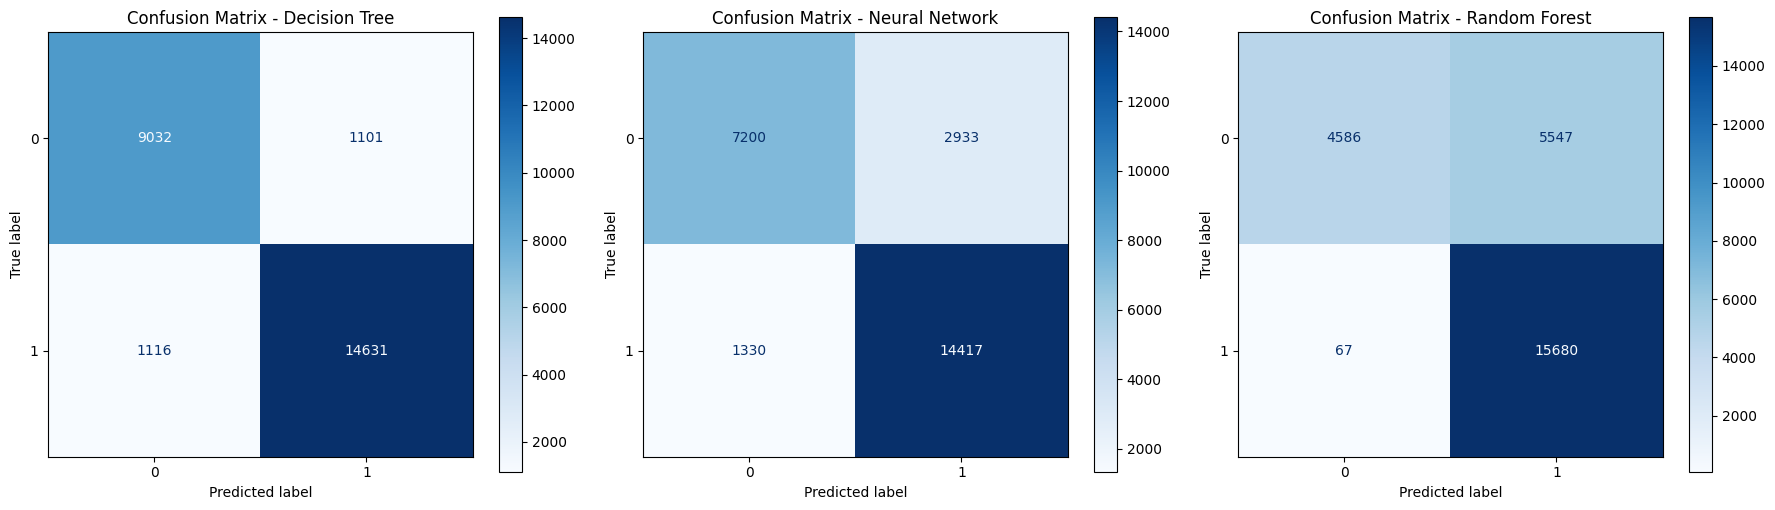

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

best_dt = gs_dt.best_estimator_
best_mlp = gs_mlp.best_estimator_
best_rf = gs_rf_clf.best_estimator_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree
ConfusionMatrixDisplay.from_estimator(best_dt, X_test_clf, y_test_clf, ax=axes[0], cmap='Blues')
axes[0].set_title("Confusion Matrix - Decision Tree")

# Neural Network
ConfusionMatrixDisplay.from_estimator(best_mlp, X_test_clf, y_test_clf, ax=axes[1], cmap='Blues')
axes[1].set_title("Confusion Matrix - Neural Network")

# Random Forest
ConfusionMatrixDisplay.from_estimator(best_rf, X_test_clf, y_test_clf, ax=axes[2], cmap='Blues')
axes[2].set_title("Confusion Matrix - Random Forest")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


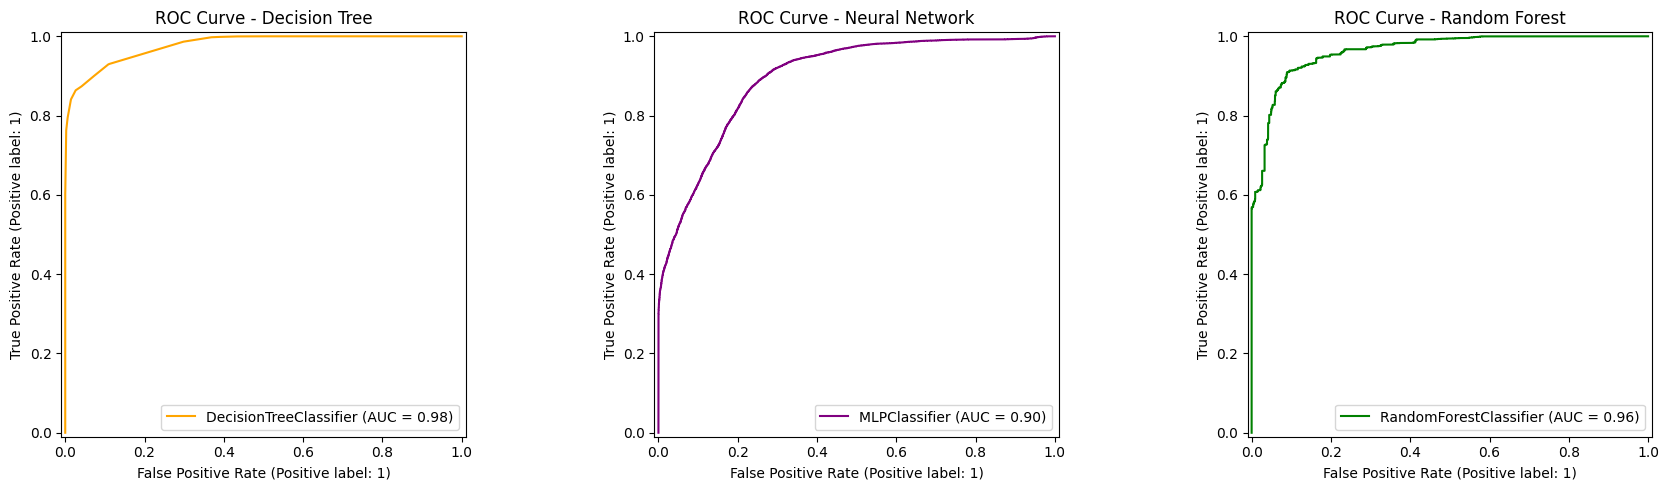

In [54]:
from sklearn.metrics import RocCurveDisplay
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree ROC Curve
RocCurveDisplay.from_estimator(best_dt, X_test_clf, y_test_clf, ax=axes[0], color='orange')
axes[0].set_title("ROC Curve - Decision Tree")

# Neural Network ROC Curve
RocCurveDisplay.from_estimator(best_mlp, X_test_clf, y_test_clf, ax=axes[1], color='purple')
axes[1].set_title("ROC Curve - Neural Network")

# Random Forest ROC Curve
RocCurveDisplay.from_estimator(best_rf, X_test_clf, y_test_clf, ax=axes[2], color='green')
axes[2].set_title("ROC Curve - Random Forest")

plt.tight_layout()
plt.show()

# **Cricket-Specific Insights**

In [55]:
print(df.columns)


Index(['Unnamed: 0_x', 'match_id', 'date', 'venue', 'city', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'winner_x', 'team1_player1',
       'team2_player1', 'team1_player2', 'team2_player2', 'team1_player3',
       'team2_player3', 'team1_player4', 'team2_player4', 'team1_player5',
       'team2_player5', 'team1_player6', 'team2_player6', 'team1_player7',
       'team2_player7', 'team1_player8', 'team2_player8', 'team1_player9',
       'team2_player9', 'team1_player10', 'team2_player10', 'team1_player11',
       'team2_player11', 'Unnamed: 0_y', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball_in_over', 'batter', 'bowler',
       'runs_off_bat', 'extras', 'is_wicket', 'wicket_type', 'player_out',
       'current_score', 'partnership_runs', 'wickets_lost', 'balls_bowled',
       'run_rate', 'target_runs', 'target_overs', 'runs_remaining',
       'balls_remaining', 'required_run_rate', 'projected_score',
       'pressure_index', 'winner_y', 'player_form', 'oppo

<Axes: title={'center': 'Team 1 Win Rate by Team'}, xlabel='team1'>

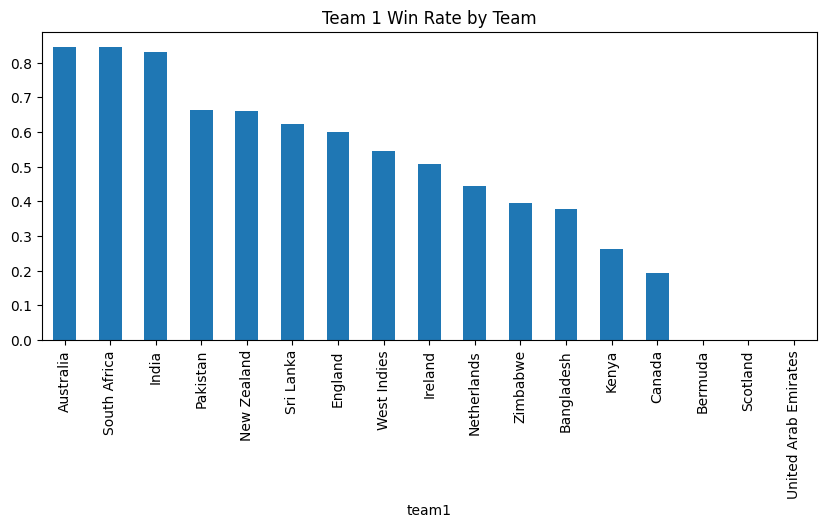

In [56]:
df['team1_win'] = (df['team1'] == df['winner_y']).astype(int)
team_win_rate = df.groupby('team1')['team1_win'].mean().sort_values(ascending=False)
team_win_rate.plot(kind='bar', figsize=(10, 4), title="Team 1 Win Rate by Team")

# **Regression Performance**

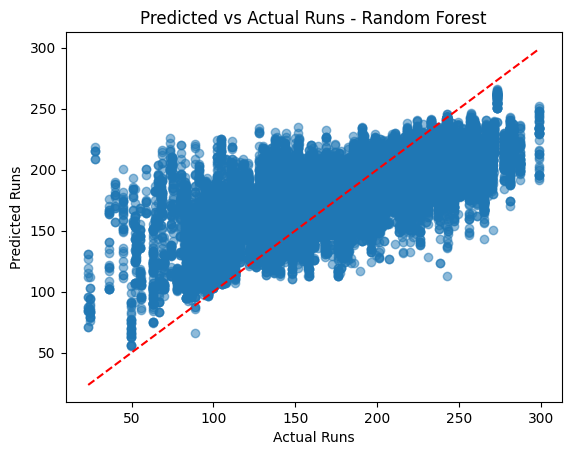

In [57]:
plt.scatter(y_test_reg, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Predicted vs Actual Runs - Random Forest")
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.show()

# **Classification Performance**

In [58]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# To store evaluation metrics
model_scores = []

def evaluate_and_store(model_name, y_true, y_pred, y_proba):
    model_scores.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba)
    })

# Use fitted GridSearchCV models and get predicted probabilities
y_pred_rf = gs_rf_clf.predict(X_test_clf)
y_proba_rf = gs_rf_clf.predict_proba(X_test_clf)[:, 1]
evaluate_and_store("Random Forest", y_test_clf, y_pred_rf, y_proba_rf)

y_pred_dt = gs_dt.predict(X_test_clf)
y_proba_dt = gs_dt.predict_proba(X_test_clf)[:, 1]
evaluate_and_store("Decision Tree", y_test_clf, y_pred_dt, y_proba_dt)

y_pred_mlp = gs_mlp.predict(X_test_clf)
y_proba_mlp = gs_mlp.predict_proba(X_test_clf)[:, 1]
evaluate_and_store("Neural Network", y_test_clf, y_pred_mlp, y_proba_mlp)

# Create summary DataFrame
summary_df = pd.DataFrame(model_scores)
summary_df = summary_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# Display summary
print(summary_df)


            Model  Accuracy  F1 Score  Precision    Recall   ROC AUC
0   Decision Tree  0.914335  0.929572   0.930015  0.929129  0.977908
1  Neural Network  0.835278  0.871197   0.830951  0.915539  0.896601
2   Random Forest  0.783076  0.848164   0.738682  0.995745  0.963405


In [59]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


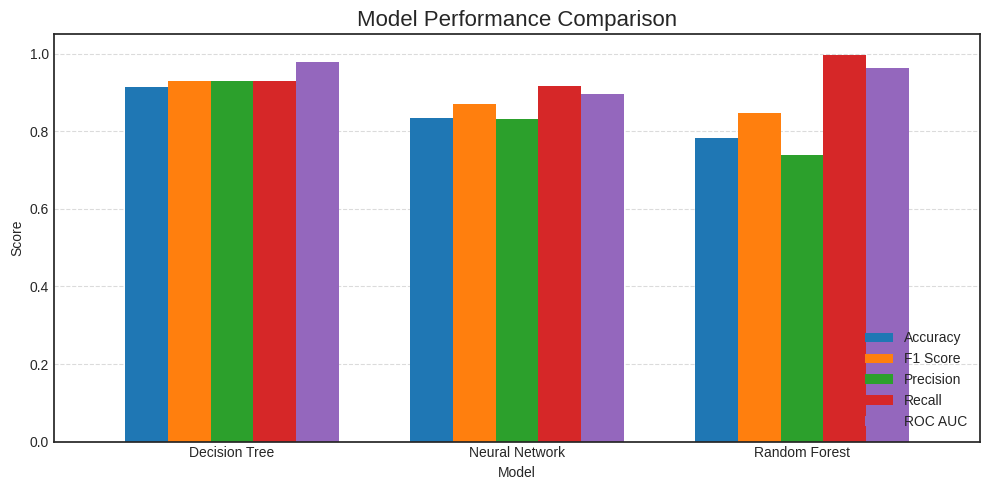

In [60]:
# Set plot style
plt.style.use('seaborn-v0_8-white')

# Plot all metrics
summary_df.set_index('Model')[['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC']]\
    .plot(kind='bar', figsize=(10, 5), width=0.75)

plt.title("Model Performance Comparison", fontsize=16)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()